# Machine Learning for Hydrology: From Basics to LSTMs

This notebook is built for a graduate hydrology / data informatics lecture.

It covers:
- ML fundamentals
- scikit-learn, PyTorch, TensorFlow, and Keras
- tree-based models
- neural networks
- RNNs and LSTMs
- a hydrology example for streamflow forecasting

## ML ecosystem: where the main tools fit

A quick framing for the class:

- **scikit-learn**: classic ML workflows, strong baselines, preprocessing, trees, linear models, metrics, and pipelines
- **PyTorch**: flexible deep learning framework, especially nice for custom sequence models and research code
- **TensorFlow**: another major deep learning framework, widely used in production and large-scale ML
- **Keras**: high-level API for building neural nets quickly; often used with TensorFlow as the backend

In practice:
- start with **scikit-learn** for baselines,
- move to **PyTorch** or **Keras/TensorFlow** when you need neural networks or sequence models.

## Lecture roadmap

1. ML basics: features, targets, train/validation/test
2. Scaling and leakage
3. scikit-learn baselines: trees and random forests
4. Neural networks in PyTorch / TensorFlow / Keras
5. Sequential data: RNNs and LSTMs
6. Hydrology example: streamflow forecasting

In [21]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import requests

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

plt.style.use("default")
np.random.seed(42)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## Data sources

The default example uses:

- **USGS daily streamflow** from the USGS Water Data API
- **Daymet daily precipitation and temperature** at the same location

You can change the site and coordinates if you want to use a different basin.

In [22]:
SITE_ID = "USGS-01646500"
LAT = 38.94977778
LON = -77.12763889

START_DATE = "2014-01-01"
END_DATE = "2024-12-31"

LOOKBACK = 30
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

## Helper functions

In [23]:
def nse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((y_true - y_pred) ** 2) / denom


def fetch_usgs_daily_discharge(site_id: str, start_date: str, end_date: str) -> pd.DataFrame:
    url = "https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily/items"
    params = {
        "f": "json",
        "monitoring_location_id": site_id,
        "parameter_code": "00060",
        "statistic_id": "00003",
        "time": f"{start_date}T00:00:00Z/{end_date}T23:59:59Z",
        "limit": 10000,
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    payload = r.json()
    rows = []
    for feat in payload.get("features", []):
        props = feat.get("properties", {})
        rows.append({
            "date": pd.to_datetime(props.get("time")).normalize(),
            "discharge_cfs": pd.to_numeric(props.get("value"), errors="coerce"),
        })
    df = pd.DataFrame(rows).dropna(subset=["date"]).sort_values("date")
    return df.drop_duplicates("date").reset_index(drop=True)


def fetch_daymet_single_pixel(lat: float, lon: float, start_date: str, end_date: str):
    url = "https://daymet.ornl.gov/single-pixel/api/data"
    params = {
        "lat": lat,
        "lon": lon,
        "vars": "prcp,tmax,tmin",
        "start": start_date,
        "end": end_date,
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    text = r.text.splitlines()
    start_idx = None
    for i, line in enumerate(text):
        if line.lower().startswith("year,"):
            start_idx = i
            break
    if start_idx is None:
        data = pd.read_csv(io.StringIO(r.text))
    else:
        data = pd.read_csv(io.StringIO("\n".join(text[start_idx:])))
    return data


def normalize_daymet(df: pd.DataFrame) -> pd.DataFrame:
    cols = {c.lower(): c for c in df.columns}
    out = df.copy()
    out["date"] = pd.to_datetime(out[cols["year"]].astype(int).astype(str)) + pd.to_timedelta(out[cols["yday"]].astype(int) - 1, unit="D")
    rename_map = {}
    for key in ["prcp", "tmax", "tmin"]:
        if key in cols:
            rename_map[cols[key]] = key
    out = out.rename(columns=rename_map)
    keep = ["date"] + [c for c in ["prcp", "tmax", "tmin"] if c in out.columns]
    return out[keep].sort_values("date").reset_index(drop=True)


def make_supervised_frame(df: pd.DataFrame, lookback: int) -> pd.DataFrame:
    out = df.copy()
    for lag in range(1, lookback + 1):
        out[f"q_lag_{lag}"] = out["discharge_cfs"].shift(lag)
        out[f"prcp_lag_{lag}"] = out["prcp"].shift(lag)
        out[f"tmax_lag_{lag}"] = out["tmax"].shift(lag)
        out[f"tmin_lag_{lag}"] = out["tmin"].shift(lag)
    out["target"] = out["discharge_cfs"].shift(-1)
    return out.dropna().reset_index(drop=True)


def chronological_split(df: pd.DataFrame, train_frac=0.7, val_frac=0.15):
    n = len(df)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

## ML basics for hydrology

Before model choice, always define:

- **features**: precipitation, temperature, lagged streamflow, snow variables
- **target**: future discharge or water level
- **training set**: data used to fit the model
- **validation set**: data used to compare options and tune hyperparameters
- **test set**: data held out for final evaluation

For hydrology, splits should respect time order. Random shuffling can create leakage.

## What the major libraries are doing for you

A useful lecture framing:

- **scikit-learn** gives you fast, reliable baselines: random forests, gradient boosting, linear models, preprocessing, pipelines, and metrics.
- **PyTorch** is best when you want custom neural architectures, especially RNNs and LSTMs, and when you want to see the internals clearly.
- **TensorFlow** is another major deep learning framework, often used in production and larger deployments.
- **Keras** makes it easier to build neural networks quickly; it is especially useful when you want a clean API for dense nets or LSTMs.

That means a common workflow is:
1. baseline in scikit-learn,
2. sequence model in PyTorch or Keras,
3. compare performance and interpret the result.

## Download the data

In [24]:
data = pd.read_csv("data/HydroDF_TuolumneRiverBasin_11274790.csv")

data = data.rename(columns={
    "Date": "date",
    "flow_cms": "discharge_cfs",
    "prcp_mm_day": "prcp",
    "tmax_C": "tmax",
    "tmin_C": "tmin"
})

data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

print("CSV data loaded:", data.shape)
display(data.head())

CSV data loaded: (5453, 46)


,date,site_no,discharge_cfs,TUM_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,dayl_s,prcp,srad_W_m2,swe_cm,...,"Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
0,2006-10-13,11274790,0.611643,0.0,0.0,0.0,39849.51,0.0,335.15,0.0,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
1,2006-10-14,11274790,0.563504,0.0,0.0,0.0,39705.43,0.0,368.37,0.0,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
2,2006-10-15,11274790,0.538019,0.0,0.0,0.0,39562.00,0.0,402.91,0.0,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
3,2006-10-16,11274790,0.504039,0.0,0.0,0.0,39419.27,0.0,342.84,0.0,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824
4,2006-10-17,11274790,0.481386,0.0,0.0,0.0,39277.27,0.0,327.94,0.0,...,0.008978,0.006413,8.326386,0.01026,37.994588,0.002565,45.493722,5.055856,0.638715,1.233824


## Exploratory plots

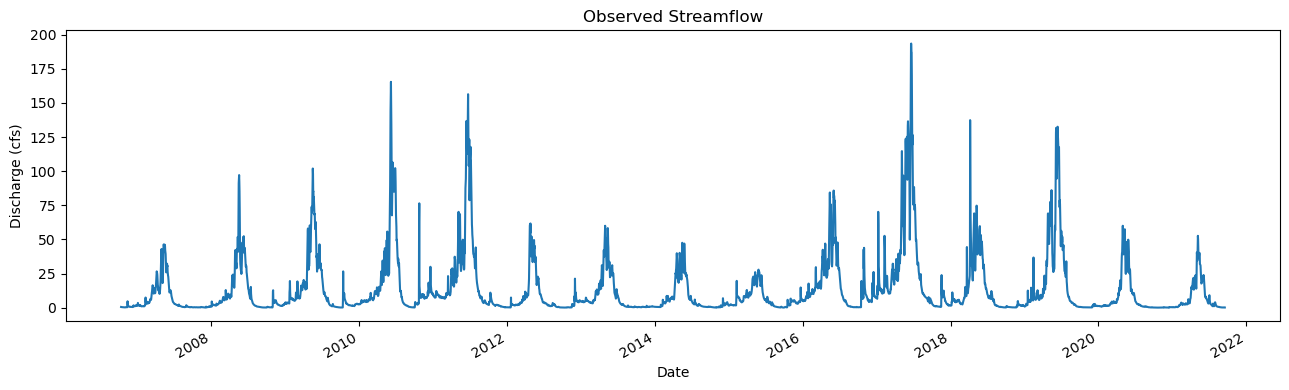

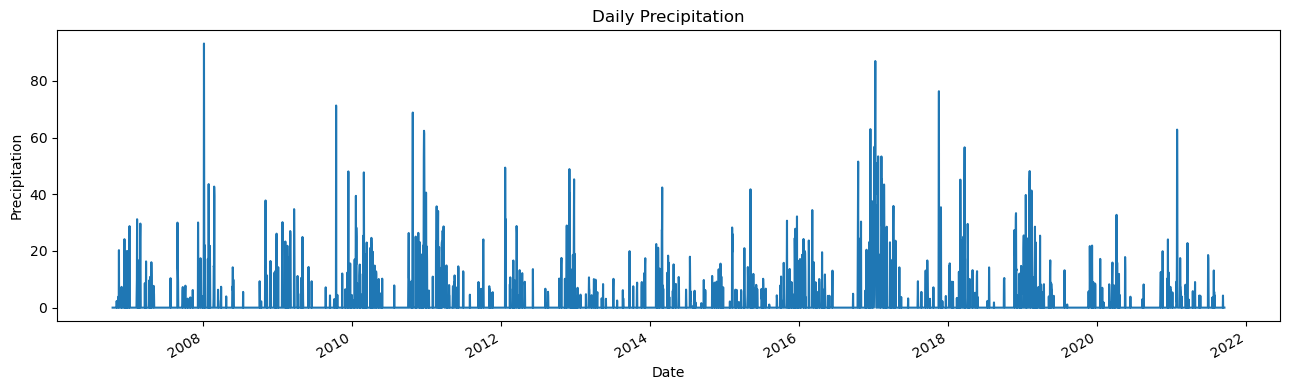

In [25]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(data["date"], data["discharge_cfs"])
ax.set_title("Observed Streamflow")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (cfs)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(data["date"], data["prcp"])
ax.set_title("Daily Precipitation")
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Baseline model: Random Forest

Tree-based models are strong baselines in hydrology because they:
- handle nonlinear relationships well,
- require little preprocessing,
- and often perform surprisingly well with lagged inputs.

The tradeoff is that they do **not** remember sequences on their own, so we need feature engineering.

In [26]:
supervised = make_supervised_frame(data, LOOKBACK)
train_df, val_df, test_df = chronological_split(supervised, TRAIN_FRAC, VAL_FRAC)

feature_cols = supervised.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "target"]
X_train = train_df[feature_cols].values
y_train = train_df["target"].values
X_test = test_df[feature_cols].values
y_test = test_df["target"].values

rf = RandomForestRegressor(n_estimators=250, random_state=42, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Random Forest MAE :", mean_absolute_error(y_test, rf_pred))
print("Random Forest NSE :", nse(y_test, rf_pred))

/scratch/local/u1257442/1071997/ipykernel_3874524/653149901.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"prcp_lag_{lag}"] = out["prcp"].shift(lag)
/scratch/local/u1257442/1071997/ipykernel_3874524/653149901.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"tmax_lag_{lag}"] = out["tmax"].shift(lag)
/scratch/local/u1257442/1071997/ipykernel_3874524/653149901.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.

Random Forest RMSE: 1.5330181248179369
Random Forest MAE : 0.6810451586763862
Random Forest NSE : 0.986210201021217


## Neural networks

Dense neural networks learn nonlinear relationships by stacking layers of weighted transformations and activation functions.

In hydrology, they are useful when:
- relationships are nonlinear,
- you have enough data,
- and you want something more flexible than a linear model.

They usually work best after scaling inputs.

## Sequence data and RNNs

Hydrologic processes have memory.

Rain today can affect streamflow tomorrow, next week, or even later through:
- soil moisture,
- snow storage,
- groundwater contributions,
- routing through the channel network.

RNNs add hidden state so the model can carry information from one time step to the next.

## LSTMs

LSTMs improve on vanilla RNNs by using gates that decide what to:
- keep,
- forget,
- and expose to the output.

That makes them useful for hydrology because basins often have long, delayed response times.

In [27]:
# Prepare sequence data for the LSTM
seq_cols = ["prcp", "tmax", "tmin", "discharge_cfs"]
full = data.dropna().copy().reset_index(drop=True)

X_seq, y_seq, dates_seq = [], [], []
for i in range(LOOKBACK, len(full) - 1):
    X_seq.append(full.loc[i-LOOKBACK:i-1, seq_cols].values)
    y_seq.append(full.loc[i + 1, "discharge_cfs"])
    dates_seq.append(full.loc[i + 1, "date"])

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)
dates_seq = np.array(dates_seq)

n = len(X_seq)
train_end = int(n * TRAIN_FRAC)
val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

X_train_seq, y_train_seq = X_seq[:train_end], y_seq[:train_end]
X_val_seq, y_val_seq = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test_seq, y_test_seq = X_seq[val_end:], y_seq[val_end:]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_scaler.fit(X_train_seq.reshape(-1, X_train_seq.shape[-1]))
y_scaler.fit(y_train_seq.reshape(-1, 1))

def scale_3d(X):
    flat = X.reshape(-1, X.shape[-1])
    flat_scaled = x_scaler.transform(flat)
    return flat_scaled.reshape(X.shape)

X_train_scaled = scale_3d(X_train_seq)
X_val_scaled = scale_3d(X_val_seq)
X_test_scaled = scale_3d(X_test_seq)

y_train_scaled = y_scaler.transform(y_train_seq.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val_seq.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test_seq.reshape(-1, 1)).ravel()

In [28]:
if TORCH_AVAILABLE:
    class StreamflowLSTM(nn.Module):
        def __init__(self, n_features, hidden_size=32):
            super().__init__()
            self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, batch_first=True)
            self.head = nn.Sequential(
                nn.Linear(hidden_size, 16),
                nn.ReLU(),
                nn.Linear(16, 1),
            )

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.head(out[:, -1, :]).squeeze(-1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = StreamflowLSTM(n_features=X_train_scaled.shape[-1]).to(device)

    train_ds = TensorDataset(torch.tensor(X_train_scaled), torch.tensor(y_train_scaled))
    val_ds = TensorDataset(torch.tensor(X_val_scaled), torch.tensor(y_val_scaled))
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    patience = 8
    wait = 0

    for epoch in range(30):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                val_loss += loss.item() * len(xb)
        val_loss /= len(val_ds)

        print(f"Epoch {epoch+1:02d} | train={train_loss:.4f} | val={val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        lstm_pred_scaled = model(torch.tensor(X_test_scaled).to(device)).detach().cpu().numpy()
    lstm_pred = y_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).ravel()

    print("LSTM RMSE:", mean_squared_error(y_test_seq, lstm_pred, squared=False))
    print("LSTM MAE :", mean_absolute_error(y_test_seq, lstm_pred))
    print("LSTM NSE :", nse(y_test_seq, lstm_pred))
else:
    print("PyTorch is not available here, but the full LSTM example is included in the notebook.")
    lstm_pred = None

PyTorch is not available here, but the full LSTM example is included in the notebook.


## Compare observed flow and predictions

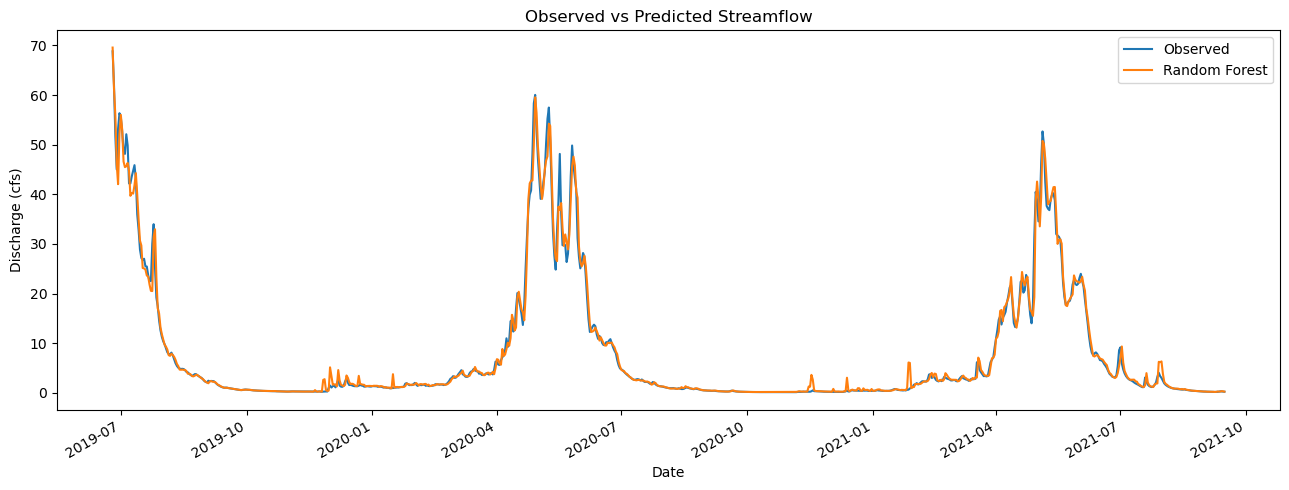

In [29]:
# Align the Random Forest target series with the LSTM test period for comparison
rf_y = y_test
rf_pred = rf_pred

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_df["date"].values, y_test, label="Observed")
ax.plot(test_df["date"].values, rf_pred, label="Random Forest")

if lstm_pred is not None:
    ax.plot(dates_seq[val_end:], lstm_pred, label="LSTM")

ax.set_title("Observed vs Predicted Streamflow")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (cfs)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## What students should notice

- scikit-learn is the easiest place to start
- tree models are excellent baselines
- neural nets need scaling and careful tuning
- RNNs/LSTMs are a natural fit when time order matters
- hydrology is full of memory and lag effects, so sequence models are especially useful

## Slide-friendly takeaways

If you use this notebook in class, the three most useful talking points are:

1. **Baseline first**: random forest or gradient boosting
2. **Sequence next**: RNNs and LSTMs for time dependence
3. **Compare fairly**: time-aware splits, scaling only on training data, and a clear evaluation metric like NSE